### LSTM Baseline Model for Residential Water Consumption Category

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dir_name = #replace with file path
df = pd.read_csv(f"{dir_name}#Replace with file name")
df.head()

,Year,Month,Residential Monthly Average,Commercial Monthly Average,Government Monthly Average,RAINFALL,TMAX,TMIN,TMEAN,WIND_SPEED,WIND_DIRECTION,RH
0,2010,1,4940168.0,702499.0,156935.0,5.080645,30.564516,23.909677,27.258065,2.354839,213.225806,84.258065
1,2010,2,3996492.0,601294.0,137278.0,0.571429,32.521429,23.550000,28.053571,2.607143,176.071429,78.071429
2,2010,3,4423759.0,654733.0,145150.0,1.706452,33.493548,24.390323,28.954839,2.741935,159.354839,78.096774
3,2010,4,4605206.0,672214.0,141869.0,4.133333,32.516667,24.800000,28.680000,2.100000,245.666667,82.166667
4,2010,5,4475865.0,642270.0,137791.0,1.848387,32.822581,25.522581,29.193548,1.903226,164.516129,83.064516


In [3]:
# Use only the Residential Monthly Average column
data = df['Residential Monthly Average'].values.reshape(-1, 1)

# Normalize the data using Min-Max Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [4]:
# Prepare the sequences
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# Define the number of time steps
time_steps = 12  # using 12 months (1 year) for each sequence
X, y = create_sequences(scaled_data, time_steps)

In [5]:
# Split the data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps, 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - loss: 0.2125 - val_loss: 0.2391
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0967 - val_loss: 0.0602
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0209 - val_loss: 0.0176
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0277 - val_loss: 0.0420
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0263 - val_loss: 0.0089
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0130 - val_loss: 0.0147
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0179 - val_loss: 0.0208
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0187 - val_loss: 0.0124
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0151 - val_loss: 0.0079
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0129 - val_loss: 0.0116
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0164 - val_loss: 0.0103
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0137 - val_l

In [7]:
# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Reverse the normalization
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate the model
train_mae = mean_absolute_error(y_train_actual, train_predictions)
test_mae = mean_absolute_error(y_test_actual, test_predictions)

print(f"Train MAE: {train_mae}")
print(f"Test MAE: {test_mae}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Train MAE: 151814.4827586207
Test MAE: 132239.22413793104


In [8]:
from google.colab import files

# Combine Year and Month columns with test set values
test_results_df = pd.DataFrame({
    'Year': df['Year'].iloc[-len(y_test_actual):].values,
    'Month': df['Month'].iloc[-len(y_test_actual):].values,
    'Actual': y_test_actual.flatten(),
    'Predicted': test_predictions.flatten()
})

# Save the DataFrame to a CSV file
test_results_df.to_csv('actual_vs_predicted_residential.csv', index=False)
files.download('actual_vs_predicted_residential.csv')

print("Actual vs. Predicted (Residential) values with Year and Month have been saved to 'actual_vs_predicted_residential.csv'")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Actual vs. Predicted (Residential) values with Year and Month have been saved to 'actual_vs_predicted_residential.csv'


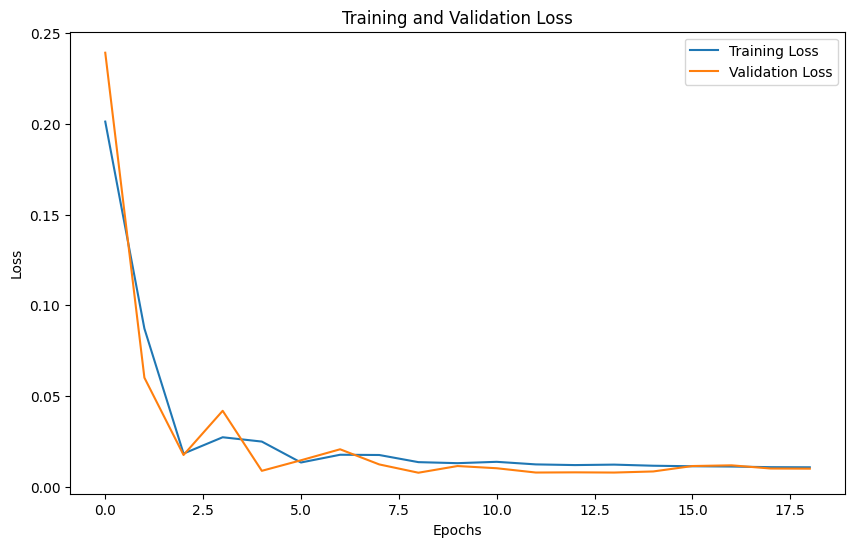

In [9]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


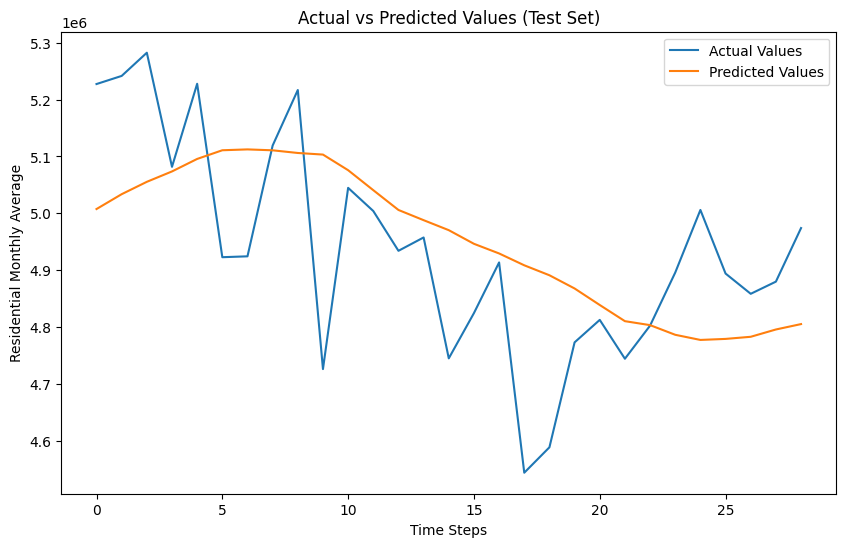

In [10]:
# Plot actual vs predicted values for test data
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label='Actual Values')
plt.plot(test_predictions, label='Predicted Values')
plt.title('Actual vs Predicted Values (Test Set)')
plt.xlabel('Time Steps')
plt.ylabel('Residential Monthly Average')
plt.legend()
plt.show()


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define a function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Calculate metrics for the test set
mae = mean_absolute_error(y_test_actual, test_predictions)
mape = mean_absolute_percentage_error(y_test_actual, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predictions))

# Print the results
print(f"Test MAE: {mae}")
print(f"Test MAPE: {mape}%")
print(f"Test RMSE: {rmse}")

Test MAE: 132239.22413793104
Test MAPE: 2.7040068689712884%
Test RMSE: 167813.41792148617
